In [5]:
import cv2
import numpy as np
import shutil
from pathlib import Path

# CÂN BẰNG SÁNG (CLAHE)
def apply_clahe(img):
    # Chuyển sang hệ LAB để chỉ can thiệp vào độ sáng (kênh L), không làm hỏng màu biển báo
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

# PHẦN 5: TĂNG CƯỜNG DỮ LIỆU (AUGMENTATION)
def add_brightness(img, value=30):
    # Tăng sáng mô phỏng trời nắng gắt
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    v = cv2.add(v, value)
    v[v > 255] = 255
    v[v < 0] = 0
    
    final_hsv = cv2.merge((h, s, v))
    return cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

def add_blur(img):
    # Làm mờ mô phỏng camera rung lắc hoặc xe chạy nhanh
    return cv2.GaussianBlur(img, (5, 5), 0)

def add_noise(img):
    # Thêm nhiễu hạt mô phỏng camera quay ban đêm chất lượng kém
    row, col, ch = img.shape
    gauss = np.random.normal(0, 15, (row, col, ch)).astype(np.float32)
    img_noisy = img.astype(np.float32) + gauss
    return np.clip(img_noisy, 0, 255).astype(np.uint8)

# THỰC THI TRÊN THƯ MỤC DỮ LIỆU
minority_classes = ['3', '4', '7', '10', '11', '13', '16', '21', '22', '25', '31', '32', '34', '35', '36', '38', '40', '43', '44', '45', '48', '49', '50', '52', '53', '57', '58', '59', '60', '61', '62', '63', '64', '66', '67', '68', '70', '71', '73', '75', '76', '77', '78', '79', '80', '81']

PROJECT_ROOT = Path.cwd().parent
INPUT_IMAGES = PROJECT_ROOT / "dataset" / "dataset" / "train" / "images"
INPUT_LABELS = PROJECT_ROOT / "dataset" / "dataset" / "train" / "labels"

OUTPUT_DIR = PROJECT_ROOT / "dataset" / "yolo_ready_train"
OUTPUT_IMAGES = OUTPUT_DIR / "images"
OUTPUT_LABELS = OUTPUT_DIR / "labels"

OUTPUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUTPUT_LABELS.mkdir(parents=True, exist_ok=True)
TARGET_SIZE = (416, 416)

print("Bắt đầu tiền xử lý có chọn lọc...")
count_total = 0
count_augmented = 0

for img_path in INPUT_IMAGES.glob("*.*"):
    if img_path.suffix.lower() in ['.jpg', '.png', '.jpeg']:
        
        img_raw = cv2.imread(str(img_path))
        label_name = img_path.stem + ".txt"
        input_label_path = INPUT_LABELS / label_name
        
        if img_raw is not None and input_label_path.exists():
            # 1. Resize ảnh
            img = cv2.resize(img_raw, TARGET_SIZE)
            
            # 2. Đọc file txt để xem ảnh này chứa Class ID nào
            with open(input_label_path, 'r') as f:
                lines = f.readlines()
            
            # Kiểm tra xem ảnh có chứa biển báo thiểu số không
            needs_augmentation = False
            for line in lines:
                class_id = line.split()[0]  # Lấy con số đầu tiên trong dòng
                if class_id in minority_classes:
                    needs_augmentation = True
                    break  # Chỉ cần có 1 biển hiếm là đủ điều kiện tăng cường
            
            # 3. LƯU ẢNH GỐC (Bắt buộc cho mọi ảnh)
            cv2.imwrite(str(OUTPUT_IMAGES / f"{img_path.stem}_ori.jpg"), img)
            shutil.copy(input_label_path, OUTPUT_LABELS / f"{img_path.stem}_ori.txt")
            count_total += 1
            
            # 4. CHỈ TĂNG CƯỜNG NẾU LÀ BIỂN BÁO HIẾM
            if needs_augmentation:
                versions = {
                    "clahe": apply_clahe(img), 
                    "bright": add_brightness(img), 
                    "blur": add_blur(img), 
                    "noise": add_noise(img) 
                }
                
                for suffix, modified_img in versions.items():
                    cv2.imwrite(str(OUTPUT_IMAGES / f"{img_path.stem}_{suffix}.jpg"), modified_img)
                    shutil.copy(input_label_path, OUTPUT_LABELS / f"{img_path.stem}_{suffix}.txt")
                
                count_augmented += 1

print(f"Xử lý xong {count_total} ảnh gốc.")
print(f"Đã phát hiện và áp dụng bộ code tăng cường cho {count_augmented} ảnh thiểu số.")

Bắt đầu tiền xử lý có chọn lọc...
Xử lý xong 8125 ảnh gốc.
Đã phát hiện và áp dụng bộ code tăng cường cho 3779 ảnh thiểu số.


Đang quét và đếm số lượng nhãn mới. Vui lòng đợi...


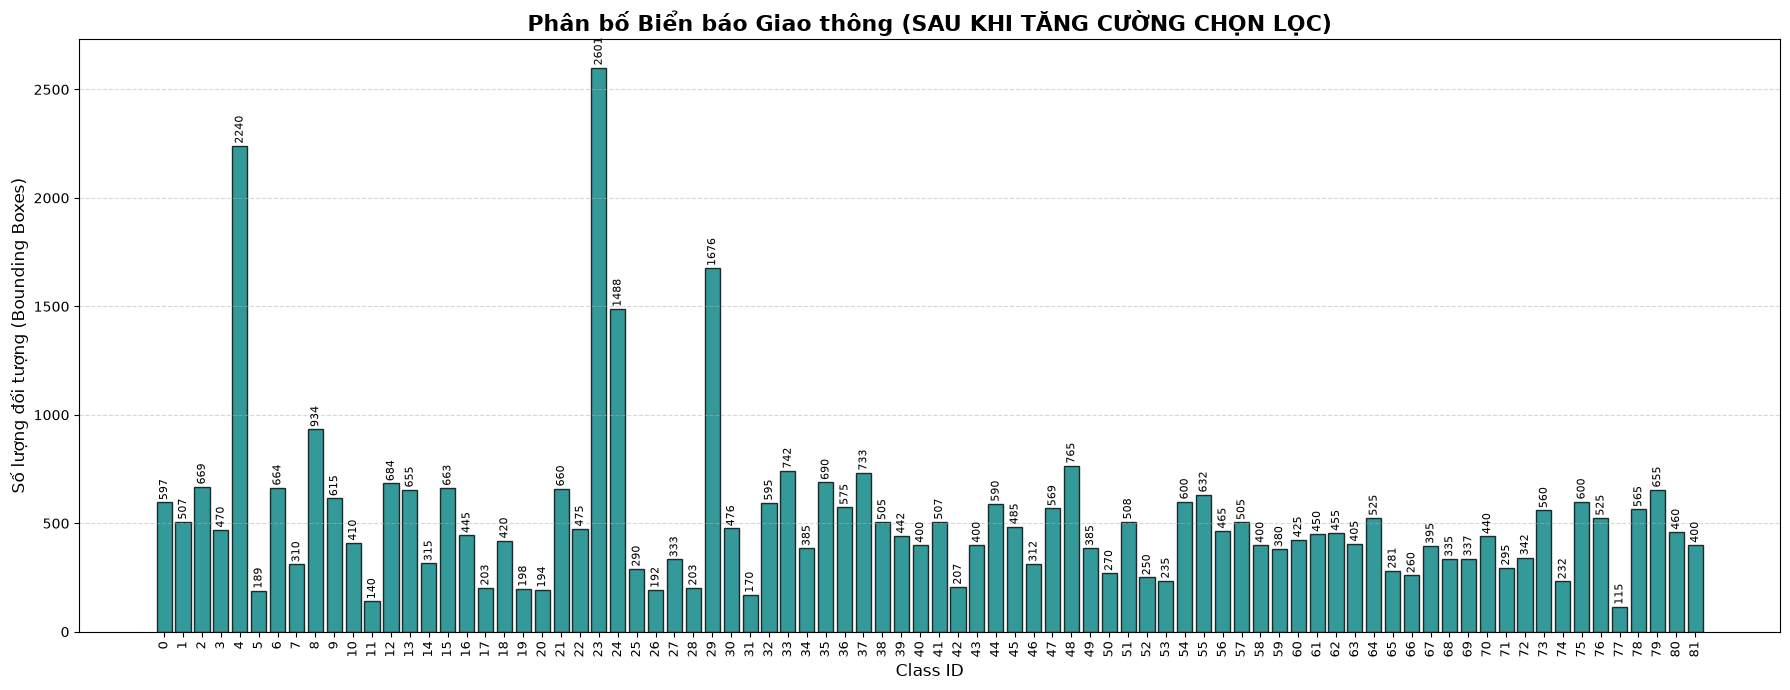

In [6]:
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# 1. Trỏ đường dẫn đến thư mục chứa file nhãn (.txt) ĐÃ XỬ LÝ
PROJECT_ROOT = Path.cwd().parent
NEW_LABELS_DIR = PROJECT_ROOT / "dataset" / "yolo_ready_train" / "labels"

print("Đang quét và đếm số lượng nhãn mới. Vui lòng đợi...")

# Khởi tạo bộ đếm
class_counts = Counter()

# 2. Lặp qua tất cả file txt mới và đếm Class ID
for txt_file in NEW_LABELS_DIR.glob("*.txt"):
    with open(txt_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0]) # Lấy con số đầu tiên làm Class ID
                class_counts[class_id] += 1

# 3. Sắp xếp dữ liệu để lên biểu đồ
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]

# 4. Vẽ biểu đồ phân bố
plt.figure(figsize=(18, 7))
bars = plt.bar(classes, counts, color='teal', edgecolor='black', alpha=0.8)

# Viết số lượng cụ thể lên đỉnh của mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), 
             ha='center', va='bottom', fontsize=8, rotation=90)

# Trang trí biểu đồ
plt.title("Phân bố Biển báo Giao thông (SAU KHI TĂNG CƯỜNG CHỌN LỌC)", fontsize=16, fontweight='bold')
plt.xlabel("Class ID", fontsize=12)
plt.ylabel("Số lượng đối tượng (Bounding Boxes)", fontsize=12)

# Hiển thị tất cả các mốc class ở trục X
plt.xticks(classes, rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tự động căn chỉnh viền
plt.tight_layout()
plt.show()

In [11]:
import yaml
import pandas as pd
PROJECT_ROOT = Path.cwd().parent

# Tập Train (đã qua tiền xử lý)
OUTPUT_IMAGES = PROJECT_ROOT / "dataset" / "yolo_ready_train" / "images"

# Tập Val (giữ nguyên gốc)
VAL_IMAGES = PROJECT_ROOT / "dataset" / "dataset" / "val" / "images"

# Đường dẫn tới file csv và nơi lưu file yaml
csv_path = PROJECT_ROOT / "dataset"/"classid.csv" 
yaml_path = PROJECT_ROOT / "data.yaml"

# 2. ĐỌC FILE CSV LẤY TÊN
df = pd.read_csv(csv_path)
class_names = df.iloc[:, 1].tolist()

# 3. TẠO CẤU TRÚC DATA.YAML 
# Sử dụng .resolve() để lấy đường dẫn tuyệt đối (Absolute Path) 
# Đảm bảo YOLO luôn tìm thấy ảnh dù bạn chạy lệnh train ở bất kỳ thư mục nào
data_yaml = {
    'train': str(OUTPUT_IMAGES.resolve()), 
    'val': str(VAL_IMAGES.resolve()),       
    'nc': len(class_names),
    'names': class_names
}

# 4. GHI RA FILE
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f, allow_unicode=True, default_flow_style=None, sort_keys=False)

print(f"Đã tạo thành công file: {yaml_path}")
print(f"Bao gồm {len(class_names)} lớp và đường dẫn tự động khớp với máy tính của bạn!") 

Đã tạo thành công file: c:\Users\TNC\Traffic-sign-project\data.yaml
Bao gồm 82 lớp và đường dẫn tự động khớp với máy tính của bạn!


1. Chiến lược Giải quyết (Tiếp cận 2 Tầng) Thay vì lạm dụng việc nhân bản dữ liệu thủ công dẫn đến rủi ro "học vẹt" (Overfitting), nhóm áp dụng chiến lược kết hợp giữa Tiền xử lý Offline (can thiệp bằng mã Python) và Tiền xử lý Online (Giao phó cho thuật toán YOLO).
Tầng 1 - Offline Augmentation (Xử lý bằng Python): Tập trung giải quyết sự thiếu hụt số lượng của 46 lớp thiểu số và xử lý các vấn đề về điểm ảnh (màu sắc, độ nét, độ sáng).
Tầng 2 - Online Augmentation (Tích hợp trong YOLO): Xử lý các vấn đề về biến đổi không gian vật lý (phóng to, thu nhỏ, che khuất, cắt ghép) thông qua thuật toán Mosaic, và xử lý triệt để phần chênh lệch dữ liệu còn lại bằng hàm mất mát Focal Loss.
2. Triển khai Kỹ thuật Tiền xử lý (Tầng 1 - Offline) Quy trình tiền xử lý được thiết kế chặt chẽ với hai luồng thực thi:
Tiền xử lý chung (Đồng bộ Kích thước): Toàn bộ ảnh đầu vào (bất kể thuộc lớp nào) đều được thay đổi kích thước về chuẩn 416x416 pixels và lưu thành bản gốc (_ori.jpg). Các tệp nhãn (.txt) dạng tọa độ chuẩn hóa YOLO được giữ nguyên để bảo toàn độ chính xác không gian.
Tăng cường Dữ liệu Chọn lọc (Selective Augmentation): Thuật toán chỉ kích hoạt quá trình nhân bản đối với 46 lớp có dưới 200 đối tượng. Mỗi ảnh thuộc nhóm thiểu số này sẽ được sinh ra thêm 4 phiên bản biến đổi, giúp đa dạng hóa bối cảnh mà không làm thay đổi hình dáng cốt lõi của biển báo:
Cân bằng Ánh sáng (CLAHE): Chuyển đổi sang hệ màu LAB và cân bằng kênh độ sáng (L) để khôi phục chi tiết cho các biển báo bị tối hụt hoặc lóa sáng.
Tăng sáng (Brightness): Đẩy giá trị kênh V (trong không gian HSV) để mô phỏng điều kiện thời tiết nắng gắt chiếu trực diện.
Làm mờ (Gaussian Blur): Mô phỏng hiện tượng nhòe ảnh do rung lắc camera khi xe di chuyển ở tốc độ cao.
Thêm nhiễu (Gaussian Noise): Mô phỏng nhiễu hạt vật lý của cảm biến camera trong điều kiện ban đêm hoặc thời tiết xấu.
3. Kết quả và Đánh giá sau Tiền xử lý
Vượt ngưỡng an toàn: Các lớp thiểu số đã được đẩy qua ngưỡng an toàn (ví dụ: Class 77 từ 23 ảnh tăng lên 115 ảnh, Class 11 từ 28 ảnh lên 140 ảnh). Điều này cung cấp đủ tính đa dạng về phông nền và biến đổi quang học, giúp mạng nơ-ron có đủ cơ sở để trích xuất đặc trưng hình học mà không bị "thiên kiến dữ liệu" (Data Bias).
Chấp nhận mất cân bằng có chủ đích: Tập dữ liệu đầu ra không cân bằng tuyệt đối (ví dụ: 115 ảnh so với 2601 ảnh). Sự chênh lệch này được giữ lại có chủ ý nhằm phản ánh đúng xác suất xuất hiện ngoài thực tế (Real-world Prior Probability) và ngăn chặn tình trạng mạng nơ-ron học thuộc lòng phông nền của các lớp thiểu số.

